# 06. Output untuk Klien

Ringkasan temuan dalam bentuk yang bisa dipahami stakeholder non-teknis: peta jaringan,
tabel rekomendasi, dan visual dampak utama. Detail metodologi ada di writeup dan notebook
01-05. Semua angka di sini dihasilkan ulang dari data, bukan diketik manual.

Figur disimpan ke `outputs/` untuk dipakai di presentasi.

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
warnings.filterwarnings("ignore")
DATA="../data/"; OUT="../outputs/"; os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"figure.dpi":110, "font.size":10})

ports  = pd.read_csv(DATA+"ports.csv").set_index("port_id")
routes = pd.read_csv(DATA+"routes_existing.csv").set_index("route_id")
orders = pd.read_csv(DATA+"orders_history_daily.csv", parse_dates=["date"])
prices = pd.read_csv(DATA+"route_prices.csv")
opex   = pd.read_csv(DATA+"route_opex_monthly.csv")

# P&L per rute (metode konsisten dgn evaluasi rute)
def blend(g):
    p=g.set_index("ticket_class").price_idr
    return (.70*p["Ekonomi"]+.25*p["Bisnis"]+.05*p["Kabin"]) if "Kabin" in p.index else (.80*p["Ekonomi"]+.20*p["Bisnis"])
pb=prices.groupby("route_id").apply(blend).rename("pblend").reset_index()
om=orders.copy(); om["month"]=om.date.dt.strftime("%Y-%m")
mt=om.groupby(["route_id","month"]).tickets_sold.sum().rename("tickets").reset_index()
mm=mt.merge(pb,on="route_id").merge(opex[["route_id","month","total_opex_idr"]],on=["route_id","month"])
mm["rev"]=mm.tickets*mm.pblend
pl=mm.groupby("route_id").agg(rev=("rev","mean"),opex=("total_opex_idr","mean"))
pl["margin_pct"]=((pl.rev-pl.opex)/pl.rev*100).round(1)
pl["margin_jt"]=((pl.rev-pl.opex)/1e6).round(0)
print("P&L per rute siap |", len(pl), "rute")

P&L per rute siap | 16 rute


## 1. Peta jaringan rute

Hijau = rute menguntungkan, merah = merugi, garis tebal biru-tua = rute wajib (tak boleh
dihapus). Garis putus-putus biru = dua rute baru yang diusulkan.

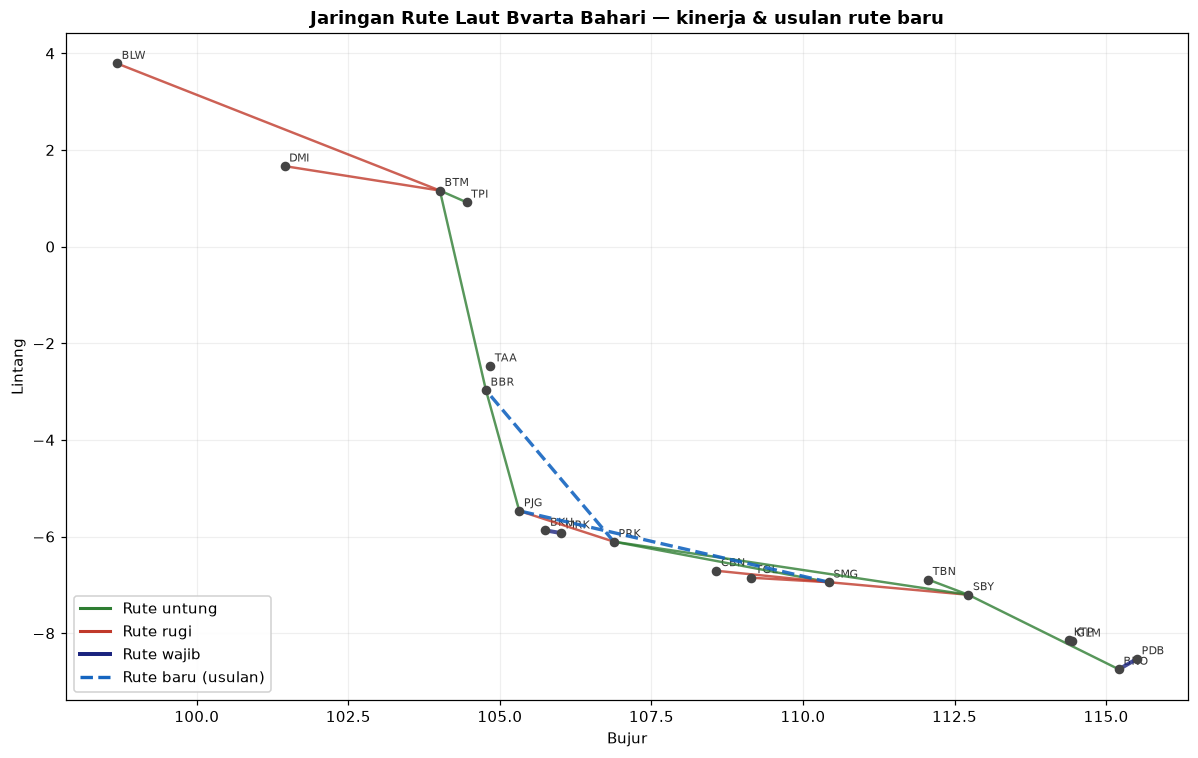

In [2]:
fig, ax = plt.subplots(figsize=(11,7))
# pelabuhan
ax.scatter(ports.lon, ports.lat, s=28, color="#444", zorder=5)
for pid,r in ports.iterrows():
    ax.annotate(pid, (r.lon, r.lat), xytext=(3,3), textcoords="offset points", fontsize=7.5, color="#333")

# rute eksisting
for rid,r in routes.iterrows():
    o,d=ports.loc[r.origin_port_id], ports.loc[r.dest_port_id]
    if r.route_type=="wajib":
        col,lw,ls="#1a237e",2.6,"-"
    else:
        col = "#2e7d32" if pl.loc[rid,"margin_pct"]>0 else "#c0392b"
        lw,ls=1.6,"-"
    ax.plot([o.lon,d.lon],[o.lat,d.lat], color=col, lw=lw, ls=ls, alpha=.8, zorder=3)

# rute baru
for o,d in [("PRK","BBR"),("SMG","PJG")]:
    a,b=ports.loc[o],ports.loc[d]
    ax.plot([a.lon,b.lon],[a.lat,b.lat], color="#1565c0", lw=2.2, ls="--", alpha=.9, zorder=4)

ax.set_xlabel("Bujur"); ax.set_ylabel("Lintang")
ax.set_title("Jaringan Rute Laut Bvarta Bahari — kinerja & usulan rute baru", fontsize=12, weight="bold")
legend=[Line2D([0],[0],color="#2e7d32",lw=2,label="Rute untung"),
        Line2D([0],[0],color="#c0392b",lw=2,label="Rute rugi"),
        Line2D([0],[0],color="#1a237e",lw=2.6,label="Rute wajib"),
        Line2D([0],[0],color="#1565c0",lw=2.2,ls="--",label="Rute baru (usulan)")]
ax.legend(handles=legend, loc="lower left", framealpha=.9)
ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(OUT+"fig_network_map.png", bbox_inches="tight"); plt.show()

## 2. Tabel rekomendasi

Satu baris per rute: kondisi saat ini dan tindakan yang disarankan dalam bahasa sederhana.

In [3]:
nm = lambda pid: ports.loc[pid,"port_name"]
rute_nama = {rid: f"{nm(r.origin_port_id)} - {nm(r.dest_port_id)}" for rid,r in routes.iterrows()}

# tindakan kurasi (disarikan dari evaluasi rute + penugasan armada)
aksi = {
 "R01":"Tambah kapal ke-2 - rute padat & paling untung",
 "R02":"Tetap jalan (wajib); tekan biaya / sesuaikan tarif",
 "R03":"Tetap jalan (wajib); efisiensi biaya operasi",
 "R04":"Pertahankan; jaga efisiensi",
 "R05":"Ganti ke kapal Passenger - pembatalan 54% turun ke ~2%",
 "R06":"Kurangi jadi 4x/minggu agar cukup 1 kapal",
 "R07":"Pertahankan, pantau",
 "R08":"Pantau; tekan biaya",
 "R09":"Pertahankan",
 "R10":"Pertahankan",
 "R11":"Tambah frekuensi - permintaan tertekan (sering penuh)",
 "R12":"Rancang ulang (ganti kelas kapal)",
 "R13":"Hentikan / realokasi kapal",
 "R14":"Hentikan / realokasi kapal",
 "R15":"Hentikan / rancang ulang",
 "R16":"Pertahankan, pantau",
}
def status_lbl(rid):
    if routes.loc[rid,"route_type"]=="wajib": return "Wajib"
    return "Untung" if pl.loc[rid,"margin_pct"]>0 else "Rugi"

rows=[]
for rid in routes.index:
    rows.append(dict(Rute=rid, Jalur=rute_nama[rid], Status=status_lbl(rid),
                     **{"Margin %":pl.loc[rid,"margin_pct"]}, Rekomendasi=aksi[rid]))
# rute baru
rows.append(dict(Rute="BARU-1", Jalur=f"{nm('PRK')} - {nm('BBR')}", Status="Usulan",
                 **{"Margin %":np.nan}, Rekomendasi="Buka (pilot) - margin positif terkuat (+4,2 M/bln)"))
rows.append(dict(Rute="BARU-2", Jalur=f"{nm('SMG')} - {nm('PJG')}", Status="Usulan",
                 **{"Margin %":np.nan}, Rekomendasi="Buka (pilot) - margin positif (+3,1 M/bln)"))
tabel=pd.DataFrame(rows)
order={"Wajib":0,"Rugi":1,"Untung":2,"Usulan":3}
tabel=tabel.sort_values(["Status","Margin %"], key=lambda s: s.map(order) if s.name=="Status" else s)
tabel.to_csv(OUT+"tabel_rekomendasi.csv", index=False)
tabel.reset_index(drop=True)

,Rute,Jalur,Status,Margin %,Rekomendasi
0,R02,Ketapang - Gilimanuk,Wajib,-58.8,Tetap jalan (wajib); tekan biaya / sesuaikan t...
1,R03,Padangbai - Benoa,Wajib,-55.7,Tetap jalan (wajib); efisiensi biaya operasi
2,R01,Merak - Bakauheni,Wajib,76.2,Tambah kapal ke-2 - rute padat & paling untung
3,R14,Tanjung Priok - Panjang,Rugi,-282.8,Hentikan / realokasi kapal
4,R13,Belawan - Batu Ampar,Rugi,-186.8,Hentikan / realokasi kapal
5,R15,Tegal - Tanjung Emas,Rugi,-119.0,Hentikan / rancang ulang
6,R05,Tanjung Emas - Tanjung Perak,Rugi,-19.3,Ganti ke kapal Passenger - pembatalan 54% turu...
7,R12,Dumai - Batu Ampar,Rugi,-12.9,Rancang ulang (ganti kelas kapal)
8,R08,Cirebon - Tanjung Emas,Rugi,-2.3,Pantau; tekan biaya
9,R09,Panjang - Boom Baru,Untung,31.9,Pertahankan


## 3. Visual dampak utama

### 3a. Untung-rugi per rute

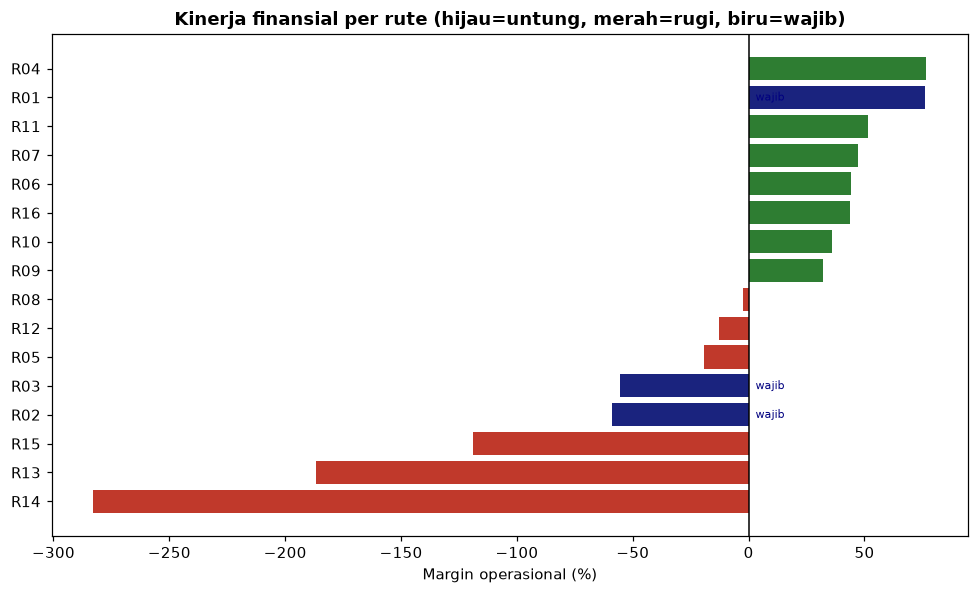

In [4]:
d=pl.sort_values("margin_pct")
colors=["#1a237e" if routes.loc[i,"route_type"]=="wajib" else ("#2e7d32" if x>0 else "#c0392b")
        for i,x in d.margin_pct.items()]
fig,ax=plt.subplots(figsize=(9,5.5))
ax.barh(d.index, d.margin_pct, color=colors)
ax.axvline(0,color="k",lw=1)
for i,(rid,row) in enumerate(d.iterrows()):
    if routes.loc[rid,"route_type"]=="wajib": ax.text(3,i,"wajib",va="center",fontsize=7,color="navy")
ax.set_xlabel("Margin operasional (%)")
ax.set_title("Kinerja finansial per rute (hijau=untung, merah=rugi, biru=wajib)", weight="bold")
plt.tight_layout(); plt.savefig(OUT+"fig_route_pnl.png", bbox_inches="tight"); plt.show()

### 3b. Dampak ganti kapal di rute SMG-SBY (R05)

Mengganti Fast Ferry dengan Passenger Ship membuat rute jauh lebih andal: dari sering batal
karena gelombang menjadi hampir selalu berlayar.

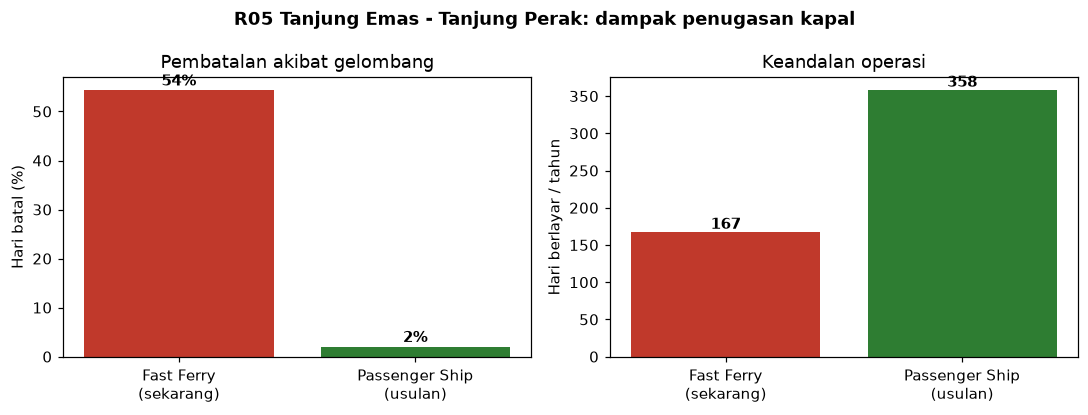

In [5]:
before, after = 0.543, 0.020   # estimasi pembatalan (dari analisis penugasan armada)
sail_b, sail_a = 365*(1-before), 365*(1-after)
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
ax[0].bar(["Fast Ferry\n(sekarang)","Passenger Ship\n(usulan)"],[before*100,after*100],color=["#c0392b","#2e7d32"])
ax[0].set_ylabel("Hari batal (%)"); ax[0].set_title("Pembatalan akibat gelombang")
for i,v in enumerate([before*100,after*100]): ax[0].text(i,v+1,f"{v:.0f}%",ha="center",weight="bold")
ax[1].bar(["Fast Ferry\n(sekarang)","Passenger Ship\n(usulan)"],[sail_b,sail_a],color=["#c0392b","#2e7d32"])
ax[1].set_ylabel("Hari berlayar / tahun"); ax[1].set_title("Keandalan operasi")
for i,v in enumerate([sail_b,sail_a]): ax[1].text(i,v+5,f"{v:.0f}",ha="center",weight="bold")
fig.suptitle("R05 Tanjung Emas - Tanjung Perak: dampak penugasan kapal", weight="bold")
plt.tight_layout(); plt.savefig(OUT+"fig_r05_reliability.png", bbox_inches="tight"); plt.show()

### 3c. Estimasi margin rute baru

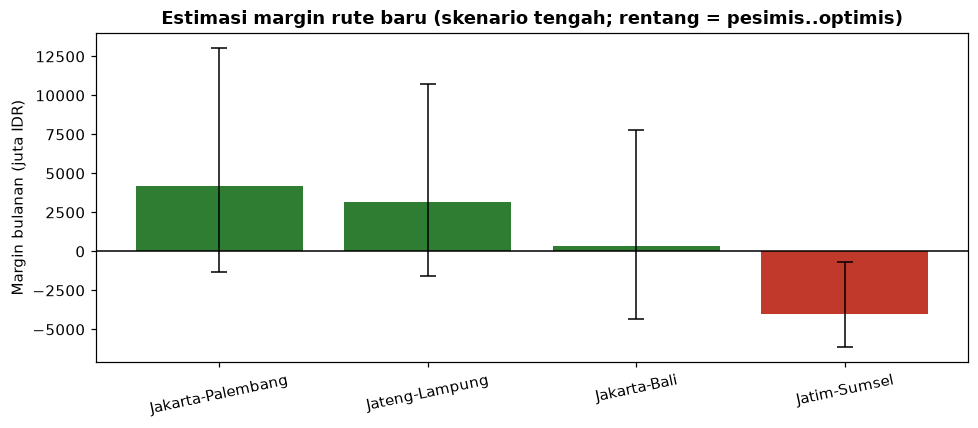

Figur tersimpan di outputs/: fig_network_map, fig_route_pnl, fig_r05_reliability, fig_new_routes (+ tabel_rekomendasi.csv)


In [6]:
new=pd.DataFrame({
  "rute":["Jakarta-Palembang","Jateng-Lampung","Jakarta-Bali","Jatim-Sumsel"],
  "pesimis":[-1298,-1581,-4339,-6135],"tengah":[4213,3142,322,-4028],"optimis":[13031,10699,7779,-657]})
new=new.sort_values("tengah",ascending=False)
fig,ax=plt.subplots(figsize=(9,4))
x=np.arange(len(new))
ax.bar(x,new.tengah,color=["#2e7d32" if m>0 else "#c0392b" for m in new.tengah])
ax.errorbar(x,new.tengah,yerr=[new.tengah-new.pesimis,new.optimis-new.tengah],fmt="none",ecolor="k",capsize=5,lw=1)
ax.axhline(0,color="k",lw=1); ax.set_xticks(x); ax.set_xticklabels(new.rute,rotation=12)
ax.set_ylabel("Margin bulanan (juta IDR)")
ax.set_title("Estimasi margin rute baru (skenario tengah; rentang = pesimis..optimis)", weight="bold")
plt.tight_layout(); plt.savefig(OUT+"fig_new_routes.png", bbox_inches="tight"); plt.show()
print("Figur tersimpan di outputs/: fig_network_map, fig_route_pnl, fig_r05_reliability, fig_new_routes (+ tabel_rekomendasi.csv)")

## 4. Tiga pesan utama untuk manajemen

1. **Permintaan rute padat bisa diprediksi** dengan akurasi yang mengalahkan tebakan musiman
   ~17%, lengkap dengan rentang ketidakpastian. Ini dasar untuk merencanakan kapasitas dan
   revenue, bukan menebak.

2. **Perbaikan terbesar ada di penugasan kapal, bukan menutup rute.** Banyak kerugian berasal
   dari kapal yang tidak cocok dengan kondisi gelombang sehingga sering batal. Menukar kelas
   kapal di rute seperti SMG-SBY memulihkan keandalan tanpa menambah rute.

3. **Ekspansi yang terukur:** tambah kapasitas di rute padat-untung (Merak-Bakauheni,
   Batam-Tanjung Pinang), buka dua rute baru lewat pilot (Jakarta-Palembang, Jateng-Lampung),
   dan hentikan/rancang-ulang rute yang rugi berat sekaligus jarang penuh.